C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


PCA Components:
        PC1       PC2  Cluster
0 -1.434678  0.152774        1
1  1.950770 -0.086823        0
2 -0.467971 -0.329206        1
3  1.695660 -0.056316        0
4 -1.137068 -0.928047        1

Explained Variance Ratio:
[0.31491585 0.27779838]

Cluster Centers:
[[ 1.65332361 -0.35714845]
 [-0.83564962 -0.48755959]
 [-0.23108115  2.42462199]]


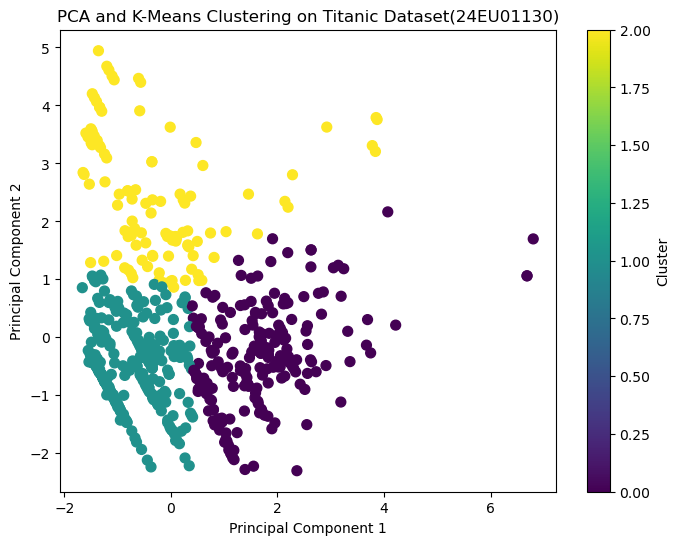

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load Titanic dataset
df = sns.load_dataset("titanic")

# Select useful numerical features
data = df[["survived", "pclass", "age", "sibsp", "parch", "fare"]]

# Remove missing values
data = data.dropna()

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Create PCA DataFrame
pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_df["Cluster"] = kmeans.fit_predict(pca_data)

# Display results
print("PCA Components:")
print(pca_df.head())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nCluster Centers:")
print(kmeans.cluster_centers_)

# Plot PCA with clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA and K-Means Clustering on Titanic Dataset(24EU01130)")
plt.colorbar(label="Cluster")
plt.show()